# Section 1: Data Cleaning

In [14]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

conn = sqlite3.connect("f1_data.db")
df_2024 = pd.read_sql("SELECT * FROM laps_2024", conn).copy()
conn.close()

print(df_2024.shape)
df_2024.head()

(27557, 9)


,Driver,LapNumber,Compound,TyreLife,LapTime,Stint,LapStartTime,Year,Race
0,NOR,1.0,MEDIUM,1.0,100424000000,1.0,3421006000000,2024,Pre-Season Testing
1,NOR,2.0,MEDIUM,2.0,98480000000,1.0,3521675000000,2024,Pre-Season Testing
2,NOR,3.0,MEDIUM,3.0,98406000000,1.0,3620155000000,2024,Pre-Season Testing
3,NOR,4.0,MEDIUM,4.0,98446000000,1.0,3718561000000,2024,Pre-Season Testing
4,NOR,5.0,MEDIUM,5.0,97938000000,1.0,3817007000000,2024,Pre-Season Testing


In [15]:
print(df_2024.dtypes)
print(df_2024.isnull().sum())
df_2024.head

Driver           object
LapNumber       float64
Compound         object
TyreLife        float64
LapTime           int64
Stint           float64
LapStartTime      int64
Year              int64
Race             object
dtype: object
Driver          0
LapNumber       0
Compound        0
TyreLife        0
LapTime         0
Stint           0
LapStartTime    0
Year            0
Race            0
dtype: int64


<bound method NDFrame.head of       Driver  LapNumber Compound  TyreLife       LapTime  Stint  \
0        NOR        1.0   MEDIUM       1.0  100424000000    1.0   
1        NOR        2.0   MEDIUM       2.0   98480000000    1.0   
2        NOR        3.0   MEDIUM       3.0   98406000000    1.0   
3        NOR        4.0   MEDIUM       4.0   98446000000    1.0   
4        NOR        5.0   MEDIUM       5.0   97938000000    1.0   
...      ...        ...      ...       ...           ...    ...   
27552    PIA       54.0     HARD      22.0   87731000000    3.0   
27553    PIA       55.0     HARD      23.0   87781000000    3.0   
27554    PIA       56.0     HARD      24.0   87816000000    3.0   
27555    PIA       57.0     HARD      25.0   88554000000    3.0   
27556    PIA       58.0     HARD      26.0   88010000000    3.0   

        LapStartTime  Year                  Race  
0      3421006000000  2024    Pre-Season Testing  
1      3521675000000  2024    Pre-Season Testing  
2      36201

In [16]:
# Remove Pre-Season Testing
df_2024 = df_2024[df_2024["Race"] != "Pre-Season Testing"]

# Convert LapTime from nanoseconds to seconds
df_2024["LapTime"] = df_2024["LapTime"] / 1e9

# Filter outlier laps (slow laps)
df_2024 = df_2024[df_2024["LapTime"] < 200]

# Filter out out-laps (first lap of each stint)
df_2024 = df_2024[df_2024["TyreLife"] > 1]

# Standardize compound names
print(df_2024["Compound"].unique())

# Info about data
print(df_2024.shape)
print(df_2024["Race"].unique())
df_2024.head()

['SOFT' 'HARD' 'MEDIUM' 'INTERMEDIATE' 'WET']
(25407, 9)
['Bahrain Grand Prix' 'Saudi Arabian Grand Prix' 'Australian Grand Prix'
 'Japanese Grand Prix' 'Chinese Grand Prix' 'Miami Grand Prix'
 'Emilia Romagna Grand Prix' 'Monaco Grand Prix' 'Canadian Grand Prix'
 'Spanish Grand Prix' 'Austrian Grand Prix' 'British Grand Prix'
 'Hungarian Grand Prix' 'Belgian Grand Prix' 'Dutch Grand Prix'
 'Italian Grand Prix' 'Azerbaijan Grand Prix' 'Singapore Grand Prix'
 'United States Grand Prix' 'Mexico City Grand Prix'
 'São Paulo Grand Prix' 'Las Vegas Grand Prix' 'Qatar Grand Prix'
 'Abu Dhabi Grand Prix']


C:\Users\arnie\AppData\Local\Temp\ipykernel_25552\3546433609.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_2024["LapTime"] = df_2024["LapTime"] / 1e9


,Driver,LapNumber,Compound,TyreLife,LapTime,Stint,LapStartTime,Year,Race
1176,VER,1.0,SOFT,4.0,97.284,1.0,3599911000000,2024,Bahrain Grand Prix
1177,VER,2.0,SOFT,5.0,96.296,1.0,3697489000000,2024,Bahrain Grand Prix
1178,VER,3.0,SOFT,6.0,96.753,1.0,3793785000000,2024,Bahrain Grand Prix
1179,VER,4.0,SOFT,7.0,96.647,1.0,3890538000000,2024,Bahrain Grand Prix
1180,VER,5.0,SOFT,8.0,97.173,1.0,3987185000000,2024,Bahrain Grand Prix


## Section 1.5: Lap Time Degradation Curves Per Compound

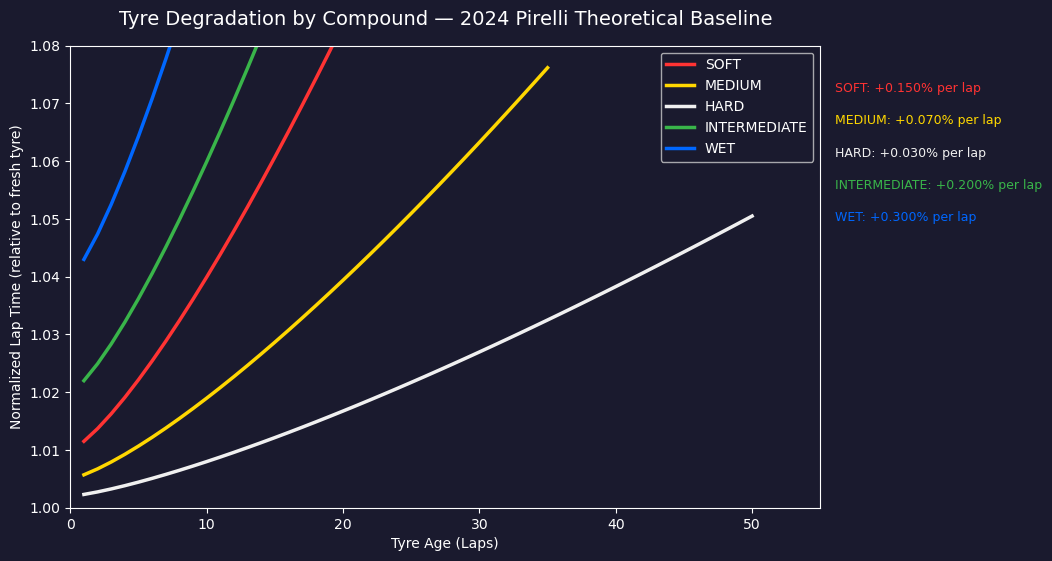

In [25]:
# Pirelli theoretical degradation rates (seconds lost per lap)
# Based on FIA/Pirelli 2024 published compound characteristics
theoretical = {
    "SOFT":         {"start": 1.010, "deg_per_lap": 0.0015, "max_laps": 20},
    "MEDIUM":       {"start": 1.005, "deg_per_lap": 0.0007, "max_laps": 35},
    "HARD":         {"start": 1.002, "deg_per_lap": 0.0003, "max_laps": 50},
    "INTERMEDIATE": {"start": 1.020, "deg_per_lap": 0.0020, "max_laps": 25},
    "WET":          {"start": 1.040, "deg_per_lap": 0.0030, "max_laps": 20},
}

colors = {
    "SOFT": "#FF3333",
    "MEDIUM": "#FFD700",
    "HARD": "#F0F0F0",
    "INTERMEDIATE": "#39B54A",
    "WET": "#0067FF"
}

fig, ax = plt.subplots(figsize=(12, 6), facecolor="#1a1a2e")
ax.set_facecolor("#1a1a2e")

for i, (compound, params) in enumerate(theoretical.items()):
    laps = np.arange(1, params["max_laps"] + 1)
    # exponential degradation curve — starts fast then cliff at end
    norm_time = params["start"] + params["deg_per_lap"] * (laps ** 1.3)

    ax.plot(laps, norm_time,
            color=colors[compound], linewidth=2.5, label=compound)

    # side annotation
    total_deg = norm_time[-1] - norm_time[0]
    ax.annotate(f"{compound}: +{params['deg_per_lap']*100:.3f}% per lap",
                xy=(1.02, 0.90 - i * 0.07),
                xycoords="axes fraction",
                color=colors[compound], fontsize=9)

ax.set_title("Tyre Degradation by Compound — 2024 Pirelli Theoretical Baseline",
             color="white", fontsize=14, pad=15)
ax.set_xlabel("Tyre Age (Laps)", color="white")
ax.set_ylabel("Normalized Lap Time (relative to fresh tyre)", color="white")
ax.tick_params(colors="white")
ax.legend(facecolor="#1a1a2e", labelcolor="white")
for spine in ax.spines.values():
    spine.set_edgecolor("white")

ax.set_xlim(0, 55)
ax.set_ylim(1.00, 1.08)
plt.subplots_adjust(right=0.75)
plt.show()